In [1]:
import json
from pathlib import Path
import pandas as pd

pd.options.display.float_format = '{:.3f}'.format
pd.set_option('display.max_rows', 50)

LAYER = 16
W = 3


def read_neuron_data(expert, layer=LAYER, w=W) -> list[dict]:
    base_dir = f"neuron_top20_titles_layer{layer}_expert{expert}_w{w}_results"
    all_data = []
    for f in Path(base_dir).glob("*.json"):
        with open(f) as fp:
            neuron_data = json.load(fp)
        all_data.append(neuron_data)
    return all_data

def get_top_20_titles(neuron_data: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame.from_records(neuron_data)
    df = df.sort_values("neuron_id")
    df = df.reset_index(drop=True)

    assert df['neuron_id'].is_unique
    assert df['neuron_id'].between(0, 14336, inclusive="left").all()
    assert (df['topics'].apply(len) == 2).all()

    df['domain.0'] = df['topics'].apply(lambda topics: topics[0]['domain'])
    df['domain.1'] = df['topics'].apply(lambda topics: topics[1]['domain'])

    df['niche.0'] = df['topics'].apply(lambda topics: topics[0]['specific_niche'])
    df['niche.1'] = df['topics'].apply(lambda topics: topics[1]['specific_niche'])

    df = df.drop(columns=['topics'])

    return df

In [2]:
neuron_data_0 = read_neuron_data(expert=0)
df_0 = get_top_20_titles(neuron_data_0)
df_0

,neuron_id,domain.0,domain.1,niche.0,niche.1
0,0,Sports,Politics,2020-2021 Seasonal Sports Leagues and Events,2020-2021 Electoral and Legislative Postponeme...
1,1,History,History,Events in Germany during the 19th century,Events in Persia during the 20th century
2,2,Food,Geography,Japanese street food and snacks,Landmarks and locations in Japan
3,3,Sports,Politics,Annual reports on the sport of athletics from ...,Legislative sessions and government policies i...
4,4,Sports Competitions,International Sports Participation,Historical Football Cup Finals,Countries in the Summer Universiade
...,...,...,...,...,...
14331,14331,Military History,Legal History,Naval Vessels and Ship Classes,Notable Legal Cases and Court Decisions
14332,14332,Climate and Environmental Science,Cultural and Social Movements,Climate Change and Global Warming,Feminist Protests and Strikes
14333,14333,History,Infrastructure,Historical events and locations in Korea,Power stations and industrial facilities in th...
14334,14334,History,Mathematics,Pacific typhoon seasons in the 19th century,Set identities and relations


In [3]:
neuron_data_1 = read_neuron_data(expert=1)
df_1 = get_top_20_titles(neuron_data_1)
df_1

,neuron_id,domain.0,domain.1,niche.0,niche.1
0,0,International Relations,Legal and Political Issues,Historical Bilateral Relations Involving Yugos...,U.S. Government Legal Challenges and Policy De...
1,1,Cyclone seasons in the North Indian Ocean,Football/soccer,Historical cyclone seasons in the North Indian...,Progression of association football goalscorin...
2,2,Politics,Entertainment,American Political Figures and Their Influence,Music and Media in Popular Culture
3,3,Sports,Sports,Combat Sports Events,World Games Participation by Nations
4,4,Companions and Guides,Media and Entertainment,Companions for Fictional Works and Practical G...,Television Shows and Sports Programming
...,...,...,...,...,...
14331,14331,Murder,Historical Events,Historical murder cases in different countries,Historical aviation accidents and military inc...
14332,14332,Politics and Governance,Science and Technology,Ballot Measures and Electoral Processes in Spe...,"Inventions, Discoveries, and Technological Con..."
14333,14333,Sports,Natural Disasters,Professional Cycling Teams and Competitions,Strong Typhoons in the Philippines
14334,14334,Biology,Computer Science,Protein structure and function,Neural networks and system architecture


In [ ]:
with open("meta_domains.json", "r") as f:
    meta_domains = json.load(f)

domain_to_meta_domain = {}
for meta_domain, domains in meta_domains.items():
    for domain in domains:
        domain_to_meta_domain[domain] = meta_domain

In [70]:
df_0['meta_domain.0'] = df_0['domain.0'].map(domain_to_meta_domain).fillna("Other")
df_0['meta_domain.1'] = df_0['domain.1'].map(domain_to_meta_domain).fillna("Other")

df_1['meta_domain.0'] = df_1['domain.0'].map(domain_to_meta_domain).fillna("Other")
df_1['meta_domain.1'] = df_1['domain.1'].map(domain_to_meta_domain).fillna("Other")

In [73]:
N_MOST_FREQUENT_DOMAINS = 8

domains_0 = pd.concat([df_0['meta_domain.0'], df_0['meta_domain.1']]).sort_index()
domains_1 = pd.concat([df_1['meta_domain.0'], df_1['domain.1']]).sort_index()

all_domains = pd.concat([domains_0, domains_1]).reset_index(drop=True)
most_frequent_domains = all_domains.value_counts().head(N_MOST_FREQUENT_DOMAINS).index

most_frequent_domains_frequencies = []
for domain in most_frequent_domains:
    freq_0 = ((df_0['meta_domain.0'].str.contains(domain)) | (df_0['meta_domain.1'].str.contains(domain))).mean()
    freq_1 = ((df_1['meta_domain.0'].str.contains(domain)) | (df_1['meta_domain.1'].str.contains(domain))).mean()

    most_frequent_domains_frequencies.append((domain, freq_0, freq_1))

freq_domains = pd.DataFrame(most_frequent_domains_frequencies, columns=['domain', 'expert_0', 'expert_1'])

freq_domains

,domain,expert_0,expert_1
0,"Arts, Culture & Entertainment",0.334,0.317
1,Other,0.270,0.292
2,Sports & Athletics,0.248,0.194
3,"Science, Technology & Medicine",0.199,0.249
4,"Politics, Government & Law",0.217,0.201
5,"History, Military & Archaeology",0.149,0.164
6,"Geography, Environment & Nature",0.165,0.136
7,"Society, Education & Religion",0.109,0.106


In [72]:
freq_domains['gap'] = freq_domains['expert_0'] - freq_domains['expert_1']
freq_domains = freq_domains.sort_values('gap', ascending=False)

freq_domains

,domain,expert_0,expert_1,gap
2,Sports & Athletics,0.248,0.194,0.054
6,"Geography, Environment & Nature",0.165,0.136,0.029
4,"Politics, Government & Law",0.217,0.201,0.017
0,"Arts, Culture & Entertainment",0.334,0.317,0.016
7,"Society, Education & Religion",0.109,0.106,0.003
5,"History, Military & Archaeology",0.149,0.164,-0.014
1,Other,0.270,0.292,-0.022
3,"Science, Technology & Medicine",0.199,0.249,-0.050


In [ ]:
# Show the address

In [ ]:
freq_domains

,expert_0,expert_1
Sports,2788,2277
Geography,1648,1135
Politics,1328,1210
History,1237,1136
Entertainment,1260,983
Technology,761,706
Biology,456,938
Music,769,575
Education,649,331
Politics and Government,463,371


In [ ]:
((df_0['domain.0'] == 'Sports') | (df_0['domain.1'] == 'Sports')).mean()

np.float64(0.17396763392857142)

In [ ]:
freq_domains['gap'] = freq_domains['expert_0'] - freq_domains['expert_1']
freq_domains = freq_domains.sort_values('gap', ascending=False)
freq_domains

,expert_0,expert_1,gap
Geography,0.145,0.117,0.028
Education,0.057,0.034,0.023
Sports,0.245,0.236,0.010
Entertainment,0.111,0.102,0.009
Music,0.068,0.060,0.008
Politics and Government,0.041,0.038,0.002
Technology,0.067,0.073,-0.006
Politics,0.117,0.125,-0.008
History,0.109,0.118,-0.009
Biology,0.040,0.097,-0.057


In [ ]:
from safetensors.torch import load_file
import pandas as pd
import polars as pl
import torch
from tqdm import tqdm
import numpy as np

EXPERT_IDS = [0, 1]
W_ID = 1
LAYER_ID = 16


if __name__ == "__main__":
    files = []
    for i in range(100):
        p = f"output_100/layer={LAYER_ID:02}/router/{i:05}.safetensors"
        files.append(p)


    row_ids = []
    titles = []
    scores = []


    for path in tqdm(files):
        tensors = []
        weights = load_file(path, device="mps")
        for k, v in weights.items():
            row_id, title = k.split(".", 1) # split left most ".":
            row_ids.append(row_id)
            titles.append(title)

            score = v[-1, EXPERT_IDS]
            scores.append(score)
    
    scores_tensor = torch.tensor(scores)
    top_1000 = torch.topk(scores_tensor, 1000, dim=0, sorted=True)
    top_1000_indices_np = top_1000.indices.cpu().numpy()
    top_1000_scores_np = top_1000.values.cpu().numpy()

    titles_np = np.array(titles)
    top_1000_titles = titles_np[top_1000_indices_np]

    df = pd.DataFrame({
        "title": top_1000_titles,
        "score": top_1000_scores_np,
    })

    df.to_csv(f"router_statistics_layer{LAYER_ID}_expert{EXPERT_ID}_w{W_ID}.csv", index=False)

In [4]:
from safetensors.torch import load_file


def load_experts_and_router(layer, file_id):
    router = load_file(f"output_100/layer={layer}/router/{file_id:05d}.safetensors", device="mps")
    experts = []
    for expert_id in range(8):
        exp = load_file(f"output_100/layer={layer}/expert={expert_id}/w=3/{file_id:05d}.safetensors", device="mps")
        print(f"Expert {expert_id} has keys: {len(exp.keys())}")
        experts.append(exp)
    return router, experts

def load_experts_and_router_multiple_files(layer, file_ids):
    agg_router = {}
    agg_experts = [{} for _ in range(8)]

    for file_id in file_ids:
        router, experts = load_experts_and_router(layer, file_id)

        agg_router.update(router)
        for expert_id in range(8):
            agg_experts[expert_id].update(experts[expert_id])
    
    assert 2 * len(agg_router) == sum(len(expert) for expert in agg_experts), "The number of router entries should be twice the number of expert entries"
    return agg_router, agg_experts

router, experts = load_experts_and_router_multiple_files(layer=16, file_ids=range(5))


Expert 0 has keys: 1134
Expert 1 has keys: 1385
Expert 2 has keys: 715
Expert 3 has keys: 61
Expert 4 has keys: 199
Expert 5 has keys: 20
Expert 6 has keys: 88
Expert 7 has keys: 398
Expert 0 has keys: 1104
Expert 1 has keys: 1377
Expert 2 has keys: 736
Expert 3 has keys: 70
Expert 4 has keys: 215
Expert 5 has keys: 26
Expert 6 has keys: 74
Expert 7 has keys: 398
Expert 0 has keys: 1066
Expert 1 has keys: 1396
Expert 2 has keys: 720
Expert 3 has keys: 71
Expert 4 has keys: 242
Expert 5 has keys: 30
Expert 6 has keys: 64
Expert 7 has keys: 411
Expert 0 has keys: 1048
Expert 1 has keys: 1438
Expert 2 has keys: 718
Expert 3 has keys: 63
Expert 4 has keys: 211
Expert 5 has keys: 33
Expert 6 has keys: 65
Expert 7 has keys: 424
Expert 0 has keys: 1024
Expert 1 has keys: 1394
Expert 2 has keys: 715
Expert 3 has keys: 79
Expert 4 has keys: 224
Expert 5 has keys: 31
Expert 6 has keys: 63
Expert 7 has keys: 470


In [5]:
import torch


top_2 = {}
top_2_stds = {}

for title_key in router.keys():
    top_2_expert_ids = torch.topk(router[title_key][-1], 2, dim=0, sorted=True).indices

    expert_1_scores = experts[top_2_expert_ids[0]][title_key]
    expert_2_scores = experts[top_2_expert_ids[1]][title_key]

    expert_1_std = torch.std(expert_1_scores)
    expert_2_std = torch.std(expert_2_scores)

    top_2[title_key] = top_2_expert_ids.cpu().numpy()
    top_2_stds[title_key] = (expert_1_std.item(), expert_2_std.item())

In [8]:
import numpy as np

Z = []

for k, v in top_2_stds.items():
    Z.append(v[0] > v[1])

np.array(Z).mean()

np.float64(0.825)

## Grouped Violin Plot: Pre-activation Standard Deviation Distribution

This visualization shows the **full distribution** of pre-activation standard deviations for 1st-choice and 2nd-choice experts across three layers (4, 16, 28).

In [8]:
from safetensors.torch import load_file
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm

def collect_std_data_for_layer(layer_id, num_files=5):
    """
    Collect standard deviation data for top-2 experts for a given layer.
    Returns a list of (expert_1_std, expert_2_std) tuples.
    """
    print(f"Loading data for layer {layer_id}...")
    
    # Load router and experts data
    agg_router = {}
    agg_experts = [{} for _ in range(8)]
    
    for file_id in tqdm(range(num_files), desc=f"Layer {layer_id}"):
        router = load_file(f"output_100/layer={layer_id:02}/router/{file_id:05d}.safetensors", device="mps")
        agg_router.update(router)
        
        for expert_id in range(8):
            exp = load_file(f"output_100/layer={layer_id:02}/expert={expert_id}/w=3/{file_id:05d}.safetensors", device="mps")
            agg_experts[expert_id].update(exp)
    
    print(f"Layer {layer_id}: Loaded {len(agg_router)} router entries")
    
    # Compute standard deviations for top-2 experts
    std_data = []
    
    for title_key in tqdm(agg_router.keys(), desc=f"Computing STDs for layer {layer_id}"):
        top_2_expert_ids = torch.topk(agg_router[title_key][-1], 2, dim=0, sorted=True).indices
        
        expert_1_scores = agg_experts[top_2_expert_ids[0]][title_key]
        expert_2_scores = agg_experts[top_2_expert_ids[1]][title_key]
        
        expert_1_std = torch.std(expert_1_scores).item()
        expert_2_std = torch.std(expert_2_scores).item()
        
        std_data.append((expert_1_std, expert_2_std))
    
    return std_data

# Load data for all three layers
layers = [4, 16, 28]
layer_std_data = {}

for layer_id in layers:
    layer_std_data[layer_id] = collect_std_data_for_layer(layer_id, num_files=5)

print(f"\n✓ Data collection complete!")

Loading data for layer 4...


Layer 4: 100%|██████████| 5/5 [00:06<00:00,  1.36s/it]


Layer 4: Loaded 10000 router entries


Computing STDs for layer 4: 100%|██████████| 10000/10000 [00:16<00:00, 623.76it/s]


Loading data for layer 16...


...

Loading data for layer 28...


Layer 28: 100%|██████████| 5/5 [00:07<00:00,  1.41s/it]


Layer 28: Loaded 10000 router entries


Computing STDs for layer 28: 100%|██████████| 10000/10000 [00:16<00:00, 592.84it/s]


✓ Data collection complete!


In [9]:
# Prepare data for violin plot
plot_data = []

for layer_id in layers:
    std_data = layer_std_data[layer_id]
    
    # Add 1st-choice expert data
    for expert_1_std, _ in std_data:
        plot_data.append({
            'Layer': layer_id,
            'Expert Choice': '1st-Choice Expert',
            'Standard Deviation': expert_1_std
        })
    
    # Add 2nd-choice expert data
    for _, expert_2_std in std_data:
        plot_data.append({
            'Layer': layer_id,
            'Expert Choice': '2nd-Choice Expert',
            'Standard Deviation': expert_2_std
        })

df_plot = pd.DataFrame(plot_data)

# Display summary statistics
print("Summary Statistics:")
print(df_plot.groupby(['Layer', 'Expert Choice'])['Standard Deviation'].describe())
print(f"\nTotal data points per layer per expert: {len(std_data):,}")

Summary Statistics:
                           count      mean       std       min       25%  \
Layer Expert Choice                                                        
4     1st-Choice Expert  10000.0  0.367162  0.053803  0.221313  0.325195   
      2nd-Choice Expert  10000.0  0.363238  0.054400  0.218262  0.321533   
16    1st-Choice Expert  10000.0  0.748876  0.055078  0.459717  0.712891   
      2nd-Choice Expert  10000.0  0.716914  0.058155  0.475098  0.673828   
28    1st-Choice Expert  10000.0  1.646971  0.214541  1.043945  1.482422   
      2nd-Choice Expert  10000.0  1.630670  0.221316  1.090820  1.464844   

                              50%       75%       max  
Layer Expert Choice                                    
4     1st-Choice Expert  0.367676  0.405029  0.558105  
      2nd-Choice Expert  0.364502  0.401855  0.529297  
16    1st-Choice Expert  0.748047  0.785645  0.990234  
      2nd-Choice Expert  0.715332  0.757812  0.960449  
28    1st-Choice Expert  1.646484  

### Difference Plot: Showing the Gap Between 1st and 2nd Choice Experts

This shows the **difference** Δσ = σ(1st-choice) - σ(2nd-choice) as a distribution.

In [13]:
# Prepare difference data
diff_data = []

for layer_id in layers:
    std_data = layer_std_data[layer_id]
    
    # Calculate difference for each data point
    for expert_1_std, expert_2_std in std_data:
        diff_data.append({
            'Layer': layer_id,
            'Difference (Δσ)': expert_1_std - expert_2_std
        })

df_diff = pd.DataFrame(diff_data)

# Display summary statistics
print("Summary Statistics for Δσ = σ(1st-choice) - σ(2nd-choice):")
print(df_diff.groupby('Layer')['Difference (Δσ)'].describe())
print(f"\nPercentage of positive differences (1st > 2nd):")
for layer_id in layers:
    pct = (df_diff[df_diff['Layer'] == layer_id]['Difference (Δσ)'] > 0).mean() * 100
    print(f"  Layer {layer_id}: {pct:.2f}%")

Summary Statistics for Δσ = σ(1st-choice) - σ(2nd-choice):
         count      mean       std       min       25%       50%       75%  \
Layer                                                                        
4      10000.0  0.003924  0.006866 -0.032959 -0.000488  0.003662  0.008301   
16     10000.0  0.031962  0.032439 -0.081543  0.007324  0.036621  0.055176   
28     10000.0  0.016302  0.078073 -0.291992 -0.030273  0.018555  0.062500   

            max  
Layer            
4      0.045166  
16     0.126953  
28     0.492188  

Percentage of positive differences (1st > 2nd):
  Layer 4: 71.08%
  Layer 16: 81.25%
  Layer 28: 62.11%


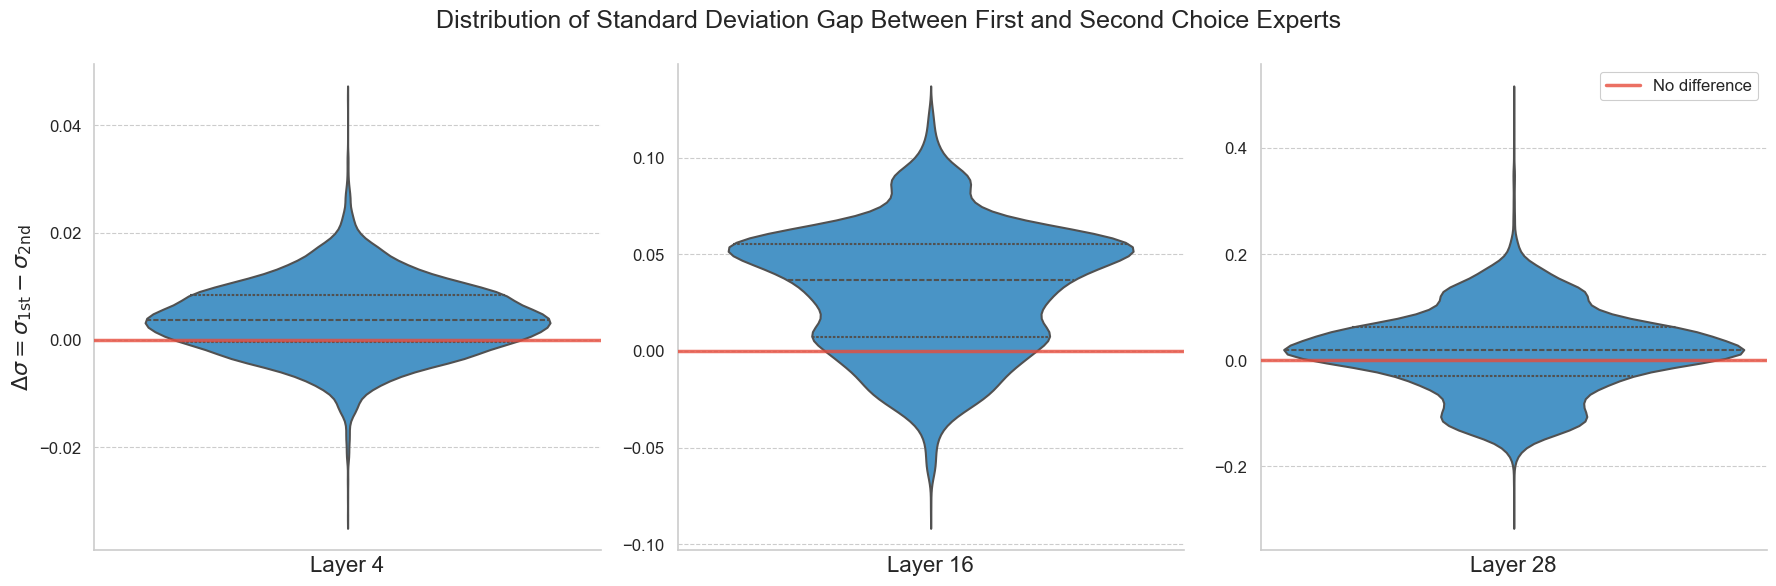


KEY FINDINGS - DIFFERENCE DISTRIBUTION:

Layer 4:
  Mean Δσ: 0.0039
  Median Δσ: 0.0037
  % where 1st > 2nd: 71.08%

Layer 16:
  Mean Δσ: 0.0320
  Median Δσ: 0.0366
  % where 1st > 2nd: 81.25%

Layer 28:
  Mean Δσ: 0.0163
  Median Δσ: 0.0186
  % where 1st > 2nd: 62.11%


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for publication-quality plots
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.linewidth'] = 0.8

# Create figure with 3 subplots (one per layer)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Professional color palette
violin_color = '#3498db'  # Professional blue
zero_line_color = '#e74c3c'  # Clean red

# Plot each layer separately
for idx, layer_id in enumerate(layers):
    ax = axes[idx]
    layer_data = df_diff[df_diff['Layer'] == layer_id]
    
    # Create violin plot for this layer
    sns.violinplot(
        data=layer_data,
        y='Difference (Δσ)',
        inner='quartile',  # Shows quartiles instead of box
        color=violin_color,
        linewidth=1.5,
        saturation=0.75,
        ax=ax
    )
    
    # Add horizontal line at y=0
    ax.axhline(y=0, color=zero_line_color, linestyle='-', linewidth=2.5, alpha=0.8, zorder=10)
    
    # Customize each subplot
    ax.set_xlabel(f'Layer {layer_id}', fontsize=16, fontweight='normal')
    if idx == 0:
        ax.set_ylabel(r'$\Delta\sigma = \sigma_{\mathrm{1st}} - \sigma_{\mathrm{2nd}}$', fontsize=16)
    else:
        ax.set_ylabel('')
    
    # Improve spine visibility
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # Remove x-axis ticks (not needed for single violin)
    ax.set_xticks([])
    ax.tick_params(axis='y', which='major', labelsize=12, width=1.2, length=6)

# Add overall title with better spacing
fig.suptitle('Distribution of Standard Deviation Gap Between First and Second Choice Experts', 
             fontsize=18, fontweight='normal', y=0.98)

# Add legend for the red line with improved styling
axes[2].plot([], [], color=zero_line_color, linestyle='-', linewidth=2.5, 
             alpha=0.8, label='No difference')
axes[2].legend(fontsize=12, loc='upper right', frameon=True, fancybox=True, 
               shadow=False, framealpha=0.95)

# Tight layout
plt.tight_layout()
plt.show()

# Print key statistics
print("\n" + "="*60)
print("KEY FINDINGS - DIFFERENCE DISTRIBUTION:")
print("="*60)
for layer_id in layers:
    layer_diff = df_diff[df_diff['Layer'] == layer_id]['Difference (Δσ)']
    mean_diff = layer_diff.mean()
    median_diff = layer_diff.median()
    positive_pct = (layer_diff > 0).mean() * 100
    
    print(f"\nLayer {layer_id}:")
    print(f"  Mean Δσ: {mean_diff:.4f}")
    print(f"  Median Δσ: {median_diff:.4f}")
    print(f"  % where 1st > 2nd: {positive_pct:.2f}%")
print("="*60)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for publication-quality plots
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.2

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors: professional blue and orange with better saturation
colors = {
    '1st-Choice Expert': '#3498db',  # Professional blue
    '2nd-Choice Expert': '#e67e22'   # Professional orange
}

# Create grouped violin plot
sns.violinplot(
    data=df_plot,
    x='Layer',
    y='Standard Deviation',
    hue='Expert Choice',
    split=False,
    palette=colors,
    inner='quartile',
    linewidth=1.5,
    saturation=0.75,
    ax=ax
)

# Customize the plot
ax.set_xlabel('Layer Index', fontsize=16)
ax.set_ylabel(r'Pre-activation Standard Deviation $\sigma(h_i)$', fontsize=16)
ax.set_title('Distribution of Pre-activation Standard Deviations\nAcross Layers and Expert Choices', 
             fontsize=18, fontweight='normal', pad=20)

# Improve legend
ax.legend(title='Expert Choice', title_fontsize=13, fontsize=12, loc='upper left',
          frameon=True, fancybox=True, shadow=False, framealpha=0.95)

# Improve spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Improve tick parameters
ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=6)

# Tight layout
plt.tight_layout()
plt.show()

# Print some key statistics
print("\n" + "="*60)
print("KEY FINDINGS:")
print("="*60)
for layer_id in layers:
    mean_1st = df_plot[(df_plot['Layer'] == layer_id) & (df_plot['Expert Choice'] == '1st-Choice Expert')]['Standard Deviation'].mean()
    mean_2nd = df_plot[(df_plot['Layer'] == layer_id) & (df_plot['Expert Choice'] == '2nd-Choice Expert')]['Standard Deviation'].mean()
    
    print(f"\nLayer {layer_id}:")
    print(f"  1st-Choice Mean: {mean_1st:.4f}")
    print(f"  2nd-Choice Mean: {mean_2nd:.4f}")
    print(f"  Difference: {mean_1st - mean_2nd:.4f} ({((mean_1st/mean_2nd - 1) * 100):.2f}% higher)")
print("="*60)

SyntaxError: invalid syntax (393793785.py, line 65)

### Alternative: Grouped Box Plot

A cleaner alternative that may be better for some publications.

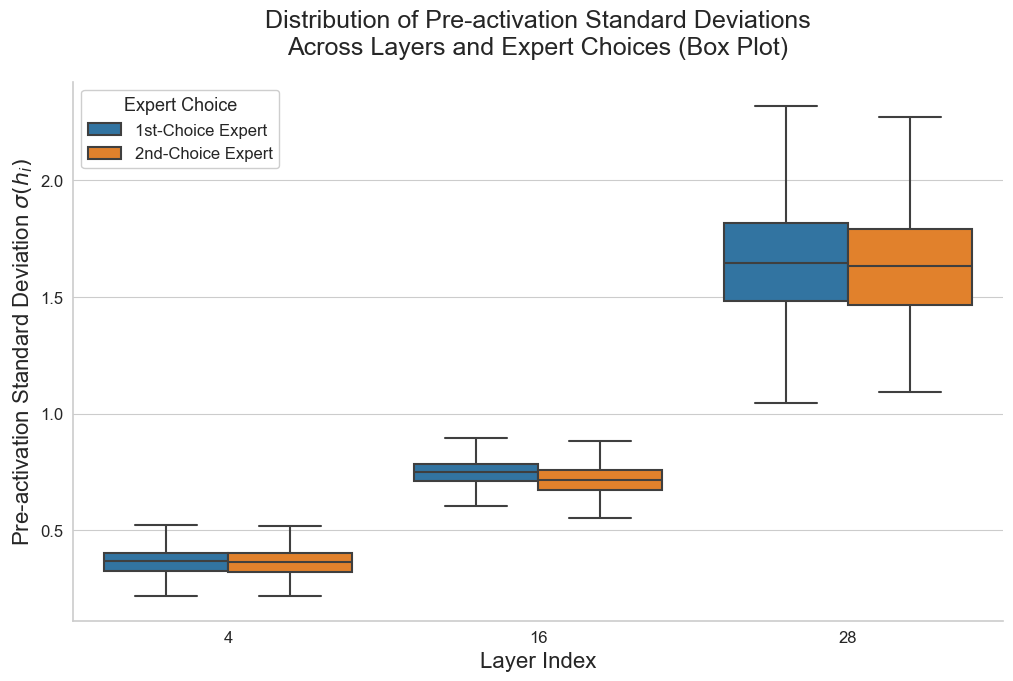

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create box plot version
fig, ax = plt.subplots(figsize=(12, 7))

# Create grouped box plot
sns.boxplot(
    data=df_plot,
    x='Layer',
    y='Standard Deviation',
    hue='Expert Choice',
    palette=colors,
    ax=ax,
    showfliers=False,  # Hide outliers for cleaner visualization
    linewidth=1.5,
    saturation=0.75
)

# Customize the plot
ax.set_xlabel('Layer Index', fontsize=16)
ax.set_ylabel(r'Pre-activation Standard Deviation $\sigma(h_i)$', fontsize=16)
ax.set_title('Distribution of Pre-activation Standard Deviations\nAcross Layers and Expert Choices (Box Plot)', 
             fontsize=18, fontweight='normal', pad=20)

# Improve legend
ax.legend(title='Expert Choice', title_fontsize=13, fontsize=12, loc='upper left',
          frameon=True, fancybox=True, shadow=False, framealpha=0.95)

# Improve spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Improve tick parameters
ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=6)

# Tight layout
plt.tight_layout()
plt.show()

### Save High-Quality Figures for Publication

In [ ]:
# Save high-quality figures
from pathlib import Path

# Create results directory if it doesn't exist
output_dir = Path("results")
output_dir.mkdir(exist_ok=True)

# Set improved style for all saved figures
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.2

# Recreate and save violin plot
fig, ax = plt.subplots(figsize=(12, 7))
sns.violinplot(
    data=df_plot,
    x='Layer',
    y='Standard Deviation',
    hue='Expert Choice',
    split=False,
    palette=colors,
    inner='quartile',
    linewidth=1.5,
    saturation=0.75,
    ax=ax
)
ax.set_xlabel('Layer Index', fontsize=16)
ax.set_ylabel(r'Pre-activation Standard Deviation $\sigma(h_i)$', fontsize=16)
ax.set_title('Distribution of Pre-activation Standard Deviations\nAcross Layers and Expert Choices', 
             fontsize=18, fontweight='normal', pad=20)
ax.legend(title='Expert Choice', title_fontsize=13, fontsize=12, loc='upper left',
          frameon=True, fancybox=True, shadow=False, framealpha=0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=6)
plt.tight_layout()
plt.savefig(output_dir / 'std_distribution_violin.png', dpi=300, bbox_inches='tight')
plt.savefig(output_dir / 'std_distribution_violin.pdf', bbox_inches='tight')
plt.close()

# Recreate and save box plot
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    data=df_plot,
    x='Layer',
    y='Standard Deviation',
    hue='Expert Choice',
    palette=colors,
    ax=ax,
    showfliers=False,
    linewidth=1.5,
    saturation=0.75
)
ax.set_xlabel('Layer Index', fontsize=16)
ax.set_ylabel(r'Pre-activation Standard Deviation $\sigma(h_i)$', fontsize=16)
ax.set_title('Distribution of Pre-activation Standard Deviations\nAcross Layers and Expert Choices (Box Plot)', 
             fontsize=18, fontweight='normal', pad=20)
ax.legend(title='Expert Choice', title_fontsize=13, fontsize=12, loc='upper left',
          frameon=True, fancybox=True, shadow=False, framealpha=0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=6)
plt.tight_layout()
plt.savefig(output_dir / 'std_distribution_boxplot.png', dpi=300, bbox_inches='tight')
plt.savefig(output_dir / 'std_distribution_boxplot.pdf', bbox_inches='tight')
plt.close()

# Recreate and save difference plot with improved style
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

violin_color = '#3498db'
zero_line_color = '#e74c3c'

for idx, layer_id in enumerate(layers):
    ax = axes[idx]
    layer_data = df_diff[df_diff['Layer'] == layer_id]
    
    sns.violinplot(
        data=layer_data,
        y='Difference (Δσ)',
        inner='quartile',
        color=violin_color,
        linewidth=1.5,
        saturation=0.75,
        ax=ax
    )
    
    ax.axhline(y=0, color=zero_line_color, linestyle='-', linewidth=2.5, alpha=0.8, zorder=10)
    ax.set_xlabel(f'Layer {layer_id}', fontsize=16, fontweight='normal')
    if idx == 0:
        ax.set_ylabel(r'$\Delta\sigma = \sigma_{\mathrm{1st}} - \sigma_{\mathrm{2nd}}$', fontsize=16)
    else:
        ax.set_ylabel('')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.set_xticks([])
    ax.tick_params(axis='y', which='major', labelsize=12, width=1.2, length=6)

fig.suptitle('Distribution of Standard Deviation Gap Between First and Second Choice Experts', 
             fontsize=18, fontweight='normal', y=0.98)
axes[2].plot([], [], color=zero_line_color, linestyle='-', linewidth=2.5, 
             alpha=0.8, label='No difference')
axes[2].legend(fontsize=12, loc='upper right', frameon=True, fancybox=True, 
               shadow=False, framealpha=0.95)
plt.tight_layout()
plt.savefig(output_dir / 'std_difference_distribution.png', dpi=300, bbox_inches='tight')
plt.savefig(output_dir / 'std_difference_distribution.pdf', bbox_inches='tight')
plt.close()

print("✓ Figures saved to:")
print(f"  - {output_dir / 'std_distribution_violin.png'}")
print(f"  - {output_dir / 'std_distribution_violin.pdf'}")
print(f"  - {output_dir / 'std_distribution_boxplot.png'}")
print(f"  - {output_dir / 'std_distribution_boxplot.pdf'}")
print(f"  - {output_dir / 'std_difference_distribution.png'}")
print(f"  - {output_dir / 'std_difference_distribution.pdf'}")

In [ ]:
# Optional: Save the data to CSV for further analysis
df_plot.to_csv(output_dir / 'std_distribution_data.csv', index=False)
df_diff.to_csv(output_dir / 'std_difference_data.csv', index=False)
print(f"✓ Data saved to:")
print(f"  - {output_dir / 'std_distribution_data.csv'}")
print(f"  - {output_dir / 'std_difference_data.csv'}")